In [1]:
import sys
import os

# Add project root to path (VERY IMPORTANT)
sys.path.append(os.path.abspath(".."))

print("Working directory:", os.getcwd())

Working directory: d:\quant-research-portfolio\quant-intraday-strategy\notebooks


In [2]:
from data.data_loader import load_kaggle_data
from strategy.signals import generate_signals
from backtest.engine import run_backtest
from analytics.performance import compute_performance

file_path = os.path.join(
    "..",
    "data",
    "global_financial_markets_2000_Now.csv"
)

df = load_kaggle_data(file_path)
df.head()

,open,high,low,close,volume
date,,,,,
2000-01-02,1394.4600,1412.4900,1384.7900,1409.2800,9.810000e+08
2000-01-03,1366.4200,1383.4600,1366.4200,1379.1899,1.274100e+09
2000-01-05,1452.4301,1481.5100,1452.4301,1468.2500,9.663000e+08
2000-01-06,1420.6000,1448.8101,1420.6000,1448.8101,9.601000e+08
2000-01-08,1430.8300,1443.5400,1428.9600,1438.1000,9.387000e+08


In [3]:
df = generate_signals(df)

df, trades, engine_results = run_backtest(
    df,
    initial_capital=1.0,
    risk_pct=0.02
)

results = compute_performance(df, trades)

results

{'final_equity': np.float64(4.982121504175192),
 'cagr': np.float64(0.06142810844320756),
 'sharpe': np.float64(0.626298844857798),
 'max_drawdown': np.float64(-0.1334578385618973),
 'total_trades': 35,
 'win_rate': 0.2857142857142857,
 'avg_win': np.float64(0.49370313041508285),
 'avg_loss': np.float64(-0.03819639199902546),
 'expectancy': np.float64(0.1137749001192912),
 'avg_holding_days': np.float64(21.514285714285716)}

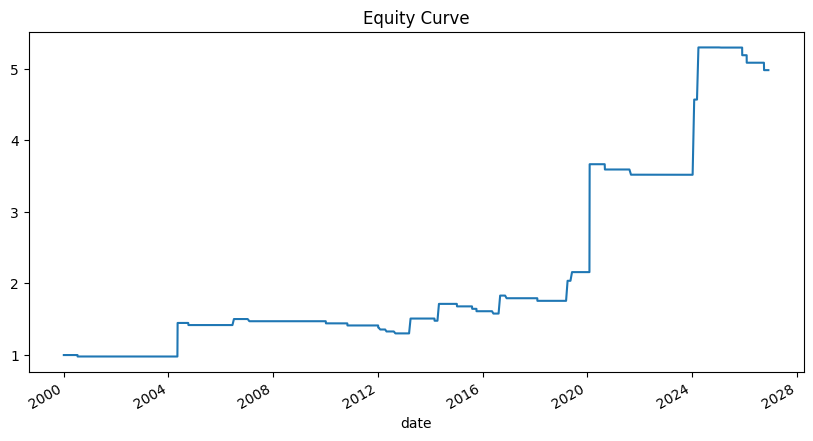

In [4]:
import matplotlib.pyplot as plt

df['equity_curve'].plot(figsize=(10,5), title="Equity Curve")
plt.show()

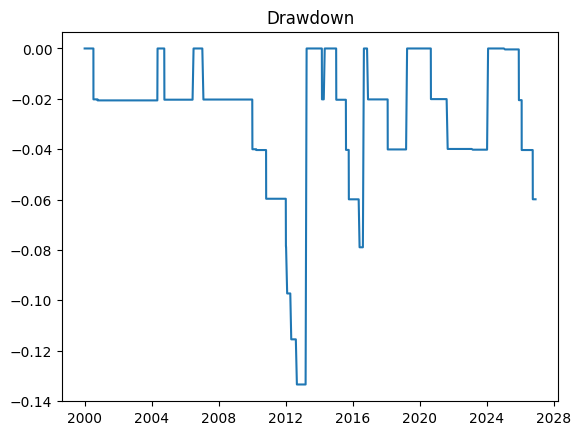

In [5]:
peak = df['equity_curve'].cummax()
dd = (df['equity_curve'] - peak) / peak

plt.plot(dd)
plt.title("Drawdown")
plt.show()

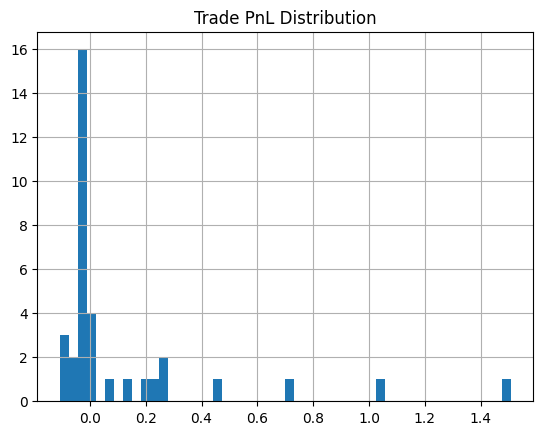

In [6]:
trades['pnl'].hist(bins=50)
plt.title("Trade PnL Distribution")
plt.show()